# Module 1 – Part B: Fraud Detection (Classification)

## Import Libraries

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Dataset

In [4]:
# Load the dataset
df = pd.read_excel("../data/Fraud/Insurance_Fraud_Claims_Dataset.xlsx",
                   sheet_name="Data")

# Display the first 5 rows
df.head()

,claim_id,customer_age,gender,policy_type,policy_tenure_years,annual_premium_inr,claim_amount_inr,incident_type,incident_severity,days_to_report,police_report_filed,witnesses,num_past_claims_3yrs,documents_complete,claim_channel,income_bracket,claim_location,fraud_reported
0,CLM500001,70,male,health,3.8,12000,61300,critical_illness,moderate,0.0,not_applicable,0,0,yes,online,6L-12L,urban,N
1,CLM500002,42,male,health,10.8,15200,60800,hospitalization,major,20.0,not_applicable,1,0,no,online,3L-6L,urban,N
2,CLM500003,60,female,health,3.3,10500,155300,critical_illness,major,1.0,not_applicable,1,0,yes,agent,3L-6L,urban,N
3,CLM500004,43,male,motor,2.1,10800,112100,collision,major,14.0,yes,1,2,yes,online,>12L,semi_urban,N
4,CLM500005,72,female,property,5.1,26000,45200,natural_disaster,minor,4.0,yes,2,0,yes,agent,3L-6L,semi_urban,N


## Data Understanding

In [3]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types and basic information
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (50000, 18)

Columns:
Index(['claim_id', 'customer_age', 'gender', 'policy_type',
       'policy_tenure_years', 'annual_premium_inr', 'claim_amount_inr',
       'incident_type', 'incident_severity', 'days_to_report',
       'police_report_filed', 'witnesses', 'num_past_claims_3yrs',
       'documents_complete', 'claim_channel', 'income_bracket',
       'claim_location', 'fraud_reported'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   claim_id              50000 non-null  object 
 1   customer_age          50000 non-null  int64  
 2   gender                50000 non-null  object 
 3   policy_type           50000 non-null  object 
 4   policy_tenure_years   50000 non-null  float64
 5   annual_premium_inr    50000 non-null  int64  
 6   claim_amount_inr      50000

,customer_age,policy_tenure_years,annual_premium_inr,claim_amount_inr,days_to_report,witnesses,num_past_claims_3yrs
count,50000.000000,50000.000000,50000.000000,5.000000e+04,49300.000000,50000.000000,50000.000000
mean,48.004980,4.408988,16707.580000,9.379630e+04,8.547789,0.905520,0.759280
std,15.889178,2.951018,8960.946943,1.157622e+05,7.406479,0.946156,1.039594
min,21.000000,0.100000,1600.000000,1.900000e+03,0.000000,0.000000,0.000000
25%,34.000000,2.200000,10500.000000,2.680000e+04,3.000000,0.000000,0.000000
50%,48.000000,3.800000,14700.000000,5.410000e+04,7.000000,1.000000,0.000000
75%,62.000000,5.900000,20700.000000,1.149000e+05,12.000000,1.000000,1.000000
max,75.000000,25.000000,118400.000000,2.509400e+06,76.000000,3.000000,4.000000


## Data Cleaning

In [4]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
claim_id                  0
customer_age              0
gender                    0
policy_type               0
policy_tenure_years       0
annual_premium_inr        0
claim_amount_inr          0
incident_type             0
incident_severity         0
days_to_report          700
police_report_filed       0
witnesses                 0
num_past_claims_3yrs      0
documents_complete        0
claim_channel             0
income_bracket            0
claim_location            0
fraud_reported            0
dtype: int64

Duplicate Rows:
0


## Handle Missing Values

In [5]:
# Fill missing values with median
df["days_to_report"].fillna(df["days_to_report"].median(), inplace=True)

# Verify missing values
print("Missing Values After Imputation:")
print(df.isnull().sum())

Missing Values After Imputation:
claim_id                0
customer_age            0
gender                  0
policy_type             0
policy_tenure_years     0
annual_premium_inr      0
claim_amount_inr        0
incident_type           0
incident_severity       0
days_to_report          0
police_report_filed     0
witnesses               0
num_past_claims_3yrs    0
documents_complete      0
claim_channel           0
income_bracket          0
claim_location          0
fraud_reported          0
dtype: int64


## Exploratory Data Analysis (EDA)

fraud_reported
N    40349
Y     9651
Name: count, dtype: int64


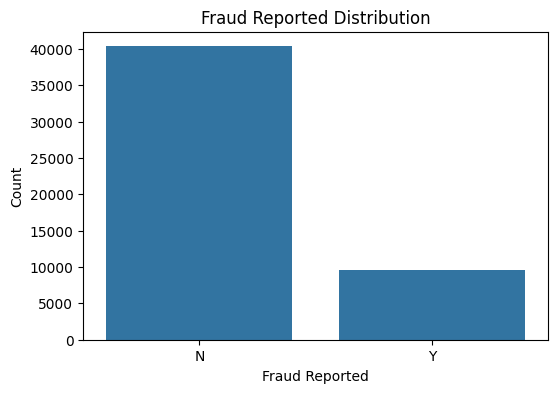

In [6]:
# Target variable distribution
print(df["fraud_reported"].value_counts())

# Visualization
plt.figure(figsize=(6,4))
sns.countplot(x="fraud_reported", data=df)
plt.title("Fraud Reported Distribution")
plt.xlabel("Fraud Reported")
plt.ylabel("Count")
plt.show()

### Customer Age Distribution

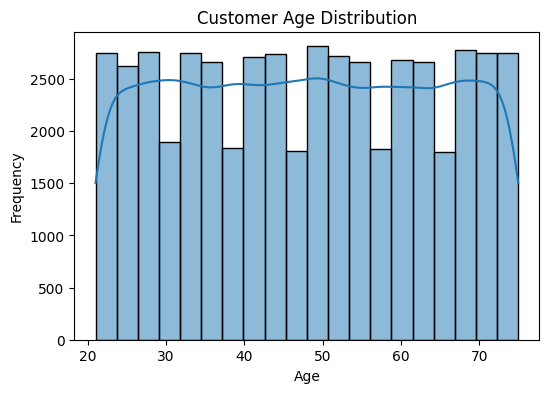

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df["customer_age"], bins=20, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Policy Type Distribution

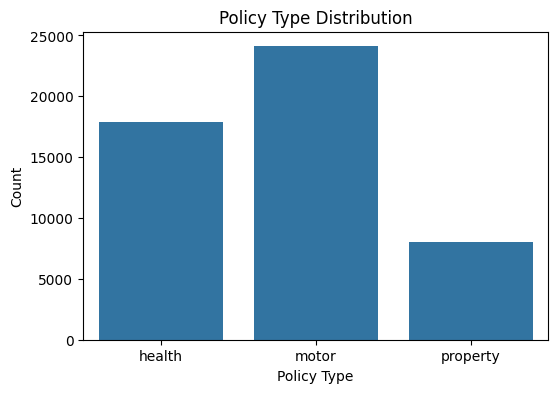

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="policy_type", data=df)
plt.title("Policy Type Distribution")
plt.xlabel("Policy Type")
plt.ylabel("Count")
plt.show()

### Incident Severity Distribution

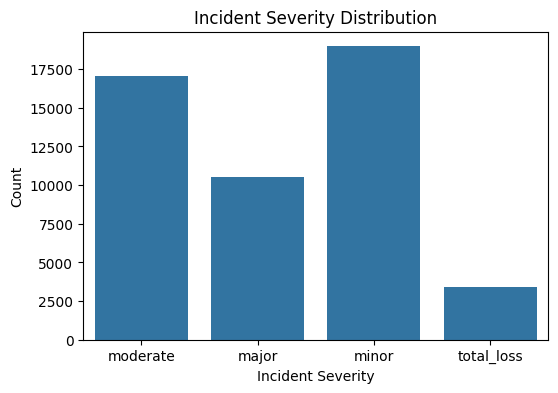

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="incident_severity", data=df)
plt.title("Incident Severity Distribution")
plt.xlabel("Incident Severity")
plt.ylabel("Count")
plt.show()

### Claim Amount Distribution

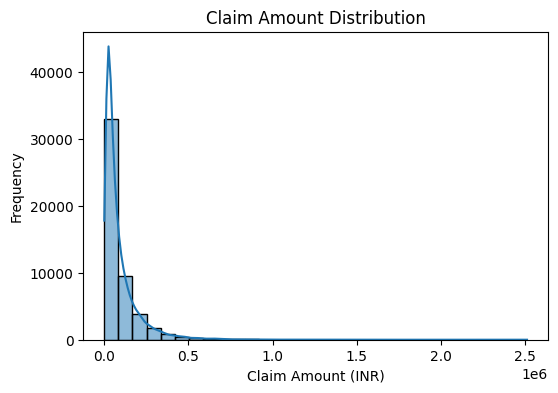

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df["claim_amount_inr"], bins=30, kde=True)
plt.title("Claim Amount Distribution")
plt.xlabel("Claim Amount (INR)")
plt.ylabel("Frequency")
plt.show()

## Feature Selection

In [7]:
# Display all column names
print(df.columns)

Index(['claim_id', 'customer_age', 'gender', 'policy_type',
       'policy_tenure_years', 'annual_premium_inr', 'claim_amount_inr',
       'incident_type', 'incident_severity', 'days_to_report',
       'police_report_filed', 'witnesses', 'num_past_claims_3yrs',
       'documents_complete', 'claim_channel', 'income_bracket',
       'claim_location', 'fraud_reported'],
      dtype='object')


In [8]:
# Drop the ID column
df.drop("claim_id", axis=1, inplace=True)

# Verify the columns
print(df.columns)

Index(['customer_age', 'gender', 'policy_type', 'policy_tenure_years',
       'annual_premium_inr', 'claim_amount_inr', 'incident_type',
       'incident_severity', 'days_to_report', 'police_report_filed',
       'witnesses', 'num_past_claims_3yrs', 'documents_complete',
       'claim_channel', 'income_bracket', 'claim_location', 'fraud_reported'],
      dtype='object')


## Features and Target

In [10]:
# Separate features and target
X = df.drop("fraud_reported", axis=1)
y = df["fraud_reported"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (50000, 16)
Target Shape: (50000,)


## Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (40000, 16)
X_test Shape: (10000, 16)
y_train Shape: (40000,)
y_test Shape: (10000,)


## Encode Categorical Features

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Fit and transform training data
X_train = preprocessor.fit_transform(X_train)

# Transform testing data
X_test = preprocessor.transform(X_test)

print("Encoding completed successfully!")
print("Encoded X_train Shape:", X_train.shape)
print("Encoded X_test Shape:", X_test.shape)

Encoding completed successfully!
Encoded X_train Shape: (40000, 40)
Encoded X_test Shape: (10000, 40)


## Handle Class Imbalance (SMOTE)

In [16]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on the training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nX_train Shape After SMOTE:", X_train_smote.shape)
print("y_train Shape After SMOTE:", y_train_smote.shape)

Before SMOTE:
fraud_reported
N    32279
Y     7721
Name: count, dtype: int64

After SMOTE:
fraud_reported
Y    32279
N    32279
Name: count, dtype: int64

X_train Shape After SMOTE: (64558, 40)
y_train Shape After SMOTE: (64558,)


## Model Training

### Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
log_reg = LogisticRegression(random_state=42)

log_reg.fit(X_train_smote, y_train_smote)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Logistic Regression Evaluation

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Make predictions
y_pred_lr = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression Performance")
print("-" * 35)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, pos_label="Y"))
print("Recall   :", recall_score(y_test, y_pred_lr, pos_label="Y"))
print("F1 Score :", f1_score(y_test, y_pred_lr, pos_label="Y"))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance
-----------------------------------
Accuracy : 0.7945
Precision: 0.47917360879706766
Recall   : 0.7450777202072539
F1 Score : 0.5832488339079295

Confusion Matrix
[[6507 1563]
 [ 492 1438]]

Classification Report
              precision    recall  f1-score   support

           N       0.93      0.81      0.86      8070
           Y       0.48      0.75      0.58      1930

    accuracy                           0.79     10000
   macro avg       0.70      0.78      0.72     10000
weighted avg       0.84      0.79      0.81     10000



### Random Forest Classifier

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Random Forest Evaluation

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Performance")
print("-" * 35)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label="Y"))
print("Recall   :", recall_score(y_test, y_pred_rf, pos_label="Y"))
print("F1 Score :", f1_score(y_test, y_pred_rf, pos_label="Y"))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
-----------------------------------
Accuracy : 0.8701
Precision: 0.7226534932956952
Recall   : 0.5305699481865285
F1 Score : 0.6118912458918434

Confusion Matrix
[[7677  393]
 [ 906 1024]]

Classification Report
              precision    recall  f1-score   support

           N       0.89      0.95      0.92      8070
           Y       0.72      0.53      0.61      1930

    accuracy                           0.87     10000
   macro avg       0.81      0.74      0.77     10000
weighted avg       0.86      0.87      0.86     10000



### XGBoost Classifier

In [21]:
from xgboost import XGBClassifier

# Convert target labels from strings to numbers
y_train_xgb = y_train_smote.map({'N': 0, 'Y': 1})
y_test_xgb = y_test.map({'N': 0, 'Y': 1})

# Train XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_xgb)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


### XGBoost Evaluation

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Performance")
print("-" * 35)

print("Accuracy :", accuracy_score(y_test_xgb, y_pred_xgb))
print("Precision:", precision_score(y_test_xgb, y_pred_xgb))
print("Recall   :", recall_score(y_test_xgb, y_pred_xgb))
print("F1 Score :", f1_score(y_test_xgb, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test_xgb, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_test_xgb, y_pred_xgb))

XGBoost Performance
-----------------------------------
Accuracy : 0.8789
Precision: 0.723430702299565
Recall   : 0.6031088082901555
F1 Score : 0.6578129415089008

Confusion Matrix
[[7625  445]
 [ 766 1164]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      8070
           1       0.72      0.60      0.66      1930

    accuracy                           0.88     10000
   macro avg       0.82      0.77      0.79     10000
weighted avg       0.87      0.88      0.87     10000



## Model Comparison

In [23]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test_xgb, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, pos_label="Y"),
        precision_score(y_test, y_pred_rf, pos_label="Y"),
        precision_score(y_test_xgb, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, pos_label="Y"),
        recall_score(y_test, y_pred_rf, pos_label="Y"),
        recall_score(y_test_xgb, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, pos_label="Y"),
        f1_score(y_test, y_pred_rf, pos_label="Y"),
        f1_score(y_test_xgb, y_pred_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7945,0.479174,0.745078,0.583249
1,Random Forest,0.8701,0.722653,0.530570,0.611891
2,XGBoost,0.8789,0.723431,0.603109,0.657813


## Save Best Model

In [24]:
import joblib

# Save the best model
joblib.dump(xgb_model, "../models/xgboost_fraud_model.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


## Save Preprocessor

In [25]:
joblib.dump(preprocessor, "../models/fraud_preprocessor.pkl")

print("Fraud preprocessor saved successfully!")

Fraud preprocessor saved successfully!
